<a href="https://colab.research.google.com/github/sashamontgomery/Neur-265/blob/main/RedoHomeworksExam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coding Homework #5

##Sasha Montgomery
*Neur 265*

<b>April 19, 2026<b>


In [ ]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#importing numpy arrays
spikes_left_trial1 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_left_trial1.csv', delimiter=",")
spikes_right_trial1 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_right_trial1.csv', delimiter=",")
spikes_left_trial2 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_left_trial2.csv', delimiter=",")
spikes_right_trial2 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_right_trial2.csv', delimiter=",")



In [ ]:
#printing length
print("spikes_left_trial1 length:",len(spikes_left_trial1 ))
print("spikes_right_trial1 length:",len(spikes_right_trial1 ))
print("spikes_left_trial2 length:",len(spikes_left_trial2 ))
print("spikes_right_trial2 length:",len(spikes_right_trial2 ))


spikes_left_trial1 length: 65
spikes_right_trial1 length: 45
spikes_left_trial2 length: 53
spikes_right_trial2 length: 69


Rats performed delayed alternation task.
- rats trained to go up the central stem of a figure 8 maze, and turn either left or right.
- rewards (chocolate sprinkles) were placed at the end of the goal arm (the arm the rat went up after it made its turn at the end of the stem
- the rat received a reward if it alternated between the two goal arms from trial to trial
- rat learned to go left on trial 1, then right trial 2, then left trial 3 etc.
- between trials, rat waited on a pedestal at the base of the maze for 30 seconds.
- Waiting period tested rat's working memory b/c had to keep in mind where it was going to go (left or right) when the 30 second waiting period was up.
- spike timestamps in four arrays were from 30 second waiting period

spikes_left_trial1 = waiting period from before first left turn tiral
spikes_right_trial1 = waiting period from first right turn trial

we want to know whether firing rate of this cell during the waiting period might predict which direction the rat turns on the upcoming trial.

In [ ]:
#determining firing rate of neuron during each trial
fr_left_trial1 = len(spikes_left_trial1 )/30
fr_right_trial1 = len(spikes_right_trial1)/30
fr_left_trial2 = len(spikes_left_trial2 )/30
fr_right_trial2 = len(spikes_right_trial2)/30
print("fr_left_trial1:",fr_left_trial1)
print("fr_left_trial2:", fr_left_trial2)
print("fr_right_trial1:",fr_right_trial1 )
print("fr_right_trial2:", fr_right_trial2)

fr_left_trial1: 2.1666666666666665
fr_left_trial2: 1.7666666666666666
fr_right_trial1: 1.5
fr_right_trial2: 2.3


The neuron does not seem to fire more before turning left or right specifically. In trial one, the neuron fired more before turning left, and in trial 2, the neuron fired more before turning right.

([], [])

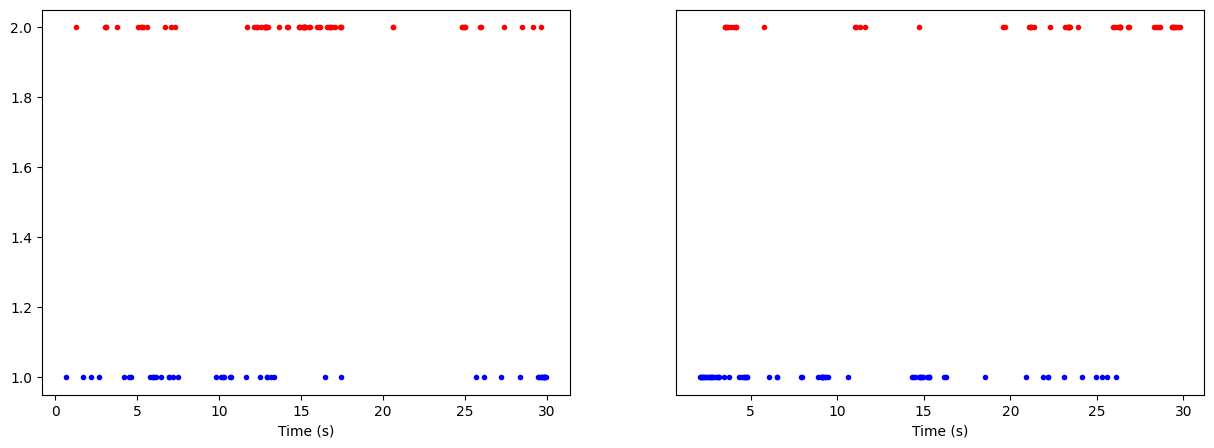

In [ ]:
#plotting spike train data
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(spikes_left_trial1, 2* np.ones_like(spikes_left_trial1), '.', color = "red")
ax[0].plot(spikes_right_trial1, 1*np.ones_like(spikes_right_trial1), '.', color = 'blue')
ax[1].plot(spikes_left_trial2,2* np.ones_like(spikes_left_trial2), '.', color = "red")
ax[1].plot(spikes_right_trial2, np.ones_like(spikes_right_trial2), '.', color = 'blue')
ax[0].set_xlabel('Time (s)')                          # ... label the x-axis
ax[1].set_xlabel('Time (s)')
plt.yticks([])                                  # ... remove y-axis ticks

#here, looking at 5 second interval of spikes


The neuron seems more bursty ??? no idea when

In [ ]:
#calculating interspike intervals
ISIs_left1 = np.diff(spikes_left_trial1)    # Compute ISIs in the low-light condition
ISIs_right1 = np.diff(spikes_right_trial1)
ISIs_left2 = np.diff(spikes_left_trial2)
ISIs_right2 = np.diff(spikes_right_trial2)


Text(0.5, 1.0, 'ISI right trial 2')

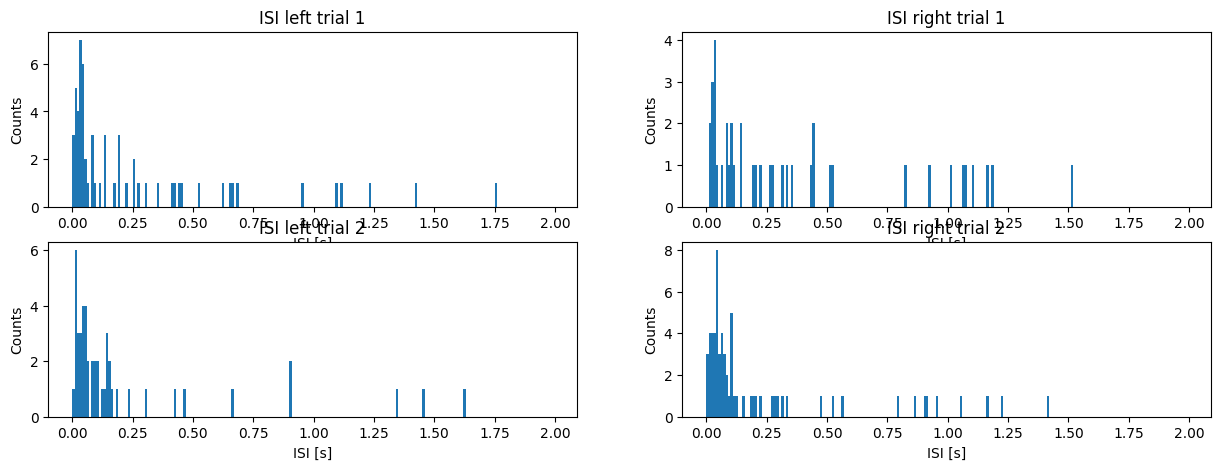

In [ ]:
#histograms of ISI arrays
bins = np.arange(0, 2, 0.01)  # Define the bins for the histogram

fig, ax = plt.subplots(2,2,figsize=(15,5))
ax[0,0].hist(ISIs_left1, bins)        # Plot the histogram of the ISI data
ax[0,0].set_xlabel('ISI [s]')              # ... label the x-axis
ax[0,0].set_ylabel('Counts')               # ... and the y-axis
ax[0,0].set_title('ISI left trial 1')             # ... give the plot a title

ax[0,1].hist(ISIs_right1, bins)        # Plot the histogram of the ISI data
ax[0,1].set_xlabel('ISI [s]')              # ... label the x-axis
ax[0,1].set_ylabel('Counts')               # ... and the y-axis
ax[0,1].set_title('ISI right trial 1')             # ... give the plot a title

ax[1,0].hist(ISIs_left2, bins)        # Plot the histogram of the ISI data
ax[1,0].set_xlabel('ISI [s]')              # ... label the x-axis
ax[1,0].set_ylabel('Counts')               # ... and the y-axis
ax[1,0].set_title('ISI left trial 2')             # ... give the plot a title

ax[1,1].hist(ISIs_right2, bins)        # Plot the histogram of the ISI data
ax[1,1].set_xlabel('ISI [s]')              # ... label the x-axis
ax[1,1].set_ylabel('Counts')               # ... and the y-axis
ax[1,1].set_title('ISI right trial 2')             # ... give the plot a title







The neurons seems to have the same burstiness in both trials no matter the direction?

Text(0, 0.5, 'Firing Rate [Hz]')

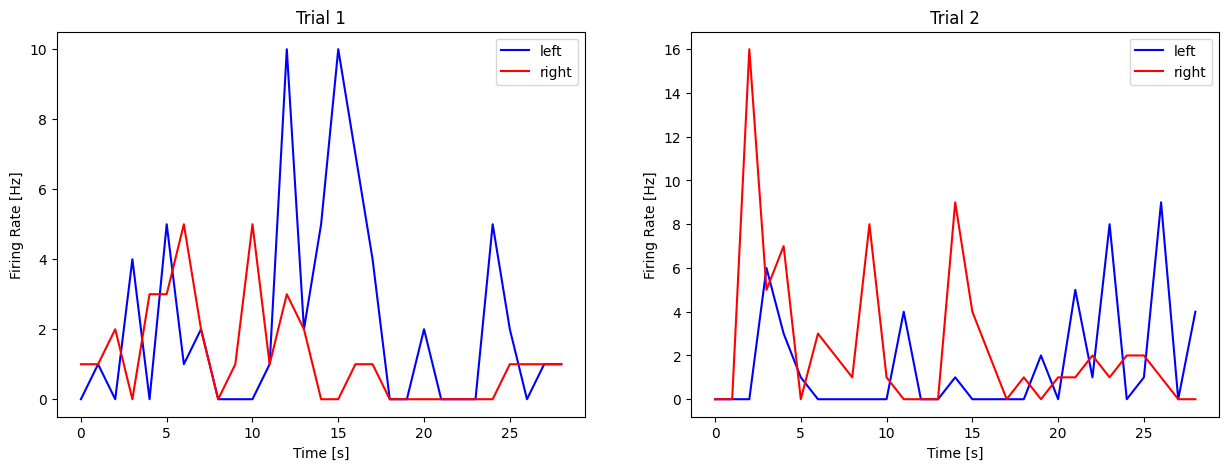

In [ ]:
binsize = 1
fr_bins = np.arange(0,30,binsize)
fr_left_trial1 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_left_trial1 > fr_bins[i]) & (spikes_left_trial1 < fr_bins[i+1])
  true_values = spikes_left_trial1[spk_index]
  fr_left_trial1[i] = (len(true_values))/binsize

fr_bins = np.arange(0,30,binsize)
fr_right_trial1 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_right_trial1 > fr_bins[i]) & (spikes_right_trial1 < fr_bins[i+1])
  true_values = spikes_right_trial1[spk_index]
  fr_right_trial1[i] = (len(true_values))/binsize

fr_bins = np.arange(0,30,binsize)
fr_left_trial2 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_left_trial2 > fr_bins[i]) & (spikes_left_trial2 < fr_bins[i+1])
  true_values = spikes_left_trial2[spk_index]
  fr_left_trial2[i] = (len(true_values))/binsize

fr_bins = np.arange(0,30,binsize)
fr_right_trial2 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_right_trial2 > fr_bins[i]) & (spikes_right_trial2 < fr_bins[i+1])
  true_values = spikes_right_trial2[spk_index]
  fr_right_trial2[i] = (len(true_values))/binsize

#plotting trial 1 and 2
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(fr_bins[:-1], fr_left_trial1, color = 'blue', label = 'left')
ax[0].plot(fr_bins[:-1], fr_right_trial1, color = 'red', label = 'right')
ax[0].legend()
ax[0].set_title('Trial 1')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Firing Rate [Hz]')

ax[1].plot(fr_bins[:-1], fr_left_trial2, color = 'blue', label = 'left')
ax[1].plot(fr_bins[:-1], fr_right_trial2, color = 'red', label = 'right')
ax[1].legend()
ax[1].set_title('Trial 2')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Firing Rate [Hz]')


#Coding Homework #6


##Sasha Montgomery
<i> NEUR 265 <i><b>

April 21, 2026 <b>

In [ ]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
#importing data sets
fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter = ',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter = ',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)




The fear_conditioning_traces array contains scaled (between 0 and 1) fluorescent traces from ROIs(indvidual cells) in the anterior cingulate cortex(ACC) of one mouse during fear conditioning and fear extinction.

Fear conditioning = the mouse is presented with an auditory tone that coincides with a mild foot-shock.
- the mouse learns to associate the tone with the foot-shock, forming a fear memory.
This mouse underwent fear conditioning, and 48 hours later, was placed back into the conditioning chamber and presented with the auditory tone to assess how well it remembered the tone/foot-shock combination.
- The tone was presented a total of 22 times
- as the tone is continously presented without the foot-shock, the mouse begins to disassociate the tone and the foot-shock, and form a neutral extinction memory.
- The cells in fear_conditioning_traces array were stably imaged across both sessions, allowing us to compare how they react across fear memory formation and extinction.

In [ ]:
#making new variables
conditioning_traces = fear_traces[:10457]
extinction_traces = fear_traces[10457:,:]


conditioning_traces.shape
extinction_traces.shape

(14211, 63)

In [ ]:
#printing traces sizes
print("conditioning_traces size:",conditioning_traces.size)
print("extinction_traces size:", extinction_traces.size)

conditioning_traces size: 658791
extinction_traces size: 895293


In [ ]:
#making time conditioning and extinction variables
time_conditioning = np.linspace(0, (10457/15), 10457)
time_extinction = np.linspace(0, (14211/15), 14211)



10458 ROIs were imaged in the conditioning traces time and 14211 were imaged in the extinction traces time.

The total length of time in seconds of the conditioning trial was 697.13 seconds or 11.62 minutes. The total length of time in seconds of the extinction trial was 947.4 seconds or 15.79 minutes.



Text(0.5, 1.0, 'Extinction Traces')

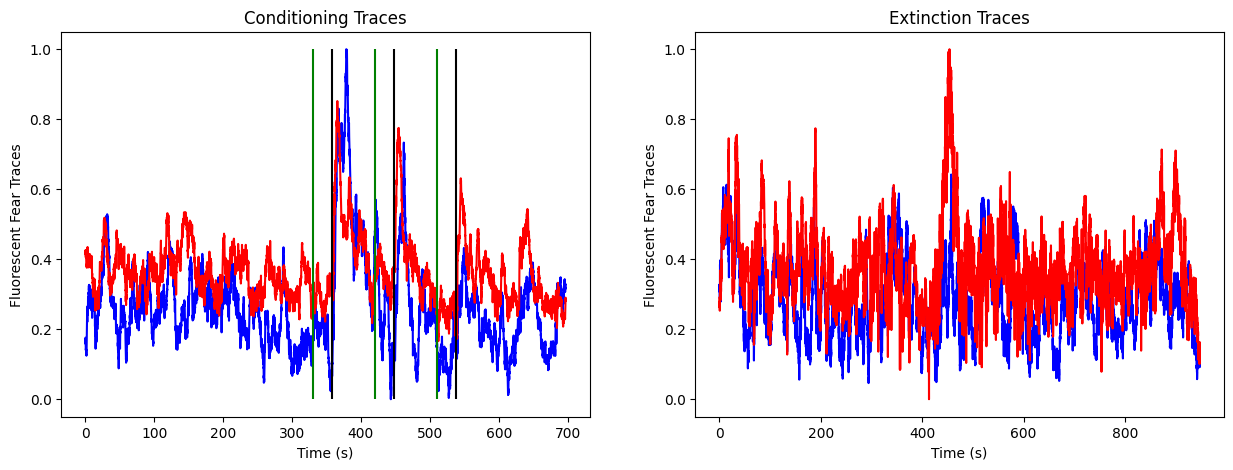

In [ ]:
#plotting ROIs
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time_conditioning,conditioning_traces[:,0], color = 'blue')
ax[0].plot(time_conditioning,conditioning_traces[:,1], color = 'red')
ax[0].vlines(shock_index, 0, 1, color ='black')
ax[0].vlines(tone_index, 0, 1, color ='green')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Fluorescent Fear Traces')
ax[0].set_title('Conditioning Traces')

ax[1].plot(time_extinction,extinction_traces[:,0], color = 'blue')
ax[1].plot(time_extinction,extinction_traces[:,1], color = 'red')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Fluorescent Fear Traces')
ax[1].set_title('Extinction Traces')


There does seem to be a relationship between conditioning/extinction traces in first ROI and the second ROI. They seem to have mostly smilar patterns of activity, with the second ROI showing slightly higher fluorescent traces. There also appears to be a relationship between how a cell responds during conditioning and how it responds during extinction, with the patterns seen in conditioning appearing similar to the ones seen in extinction.

In [ ]:
#making predictors_conditioning variable
shock_array = np.zeros(10457)
for i in range(10457):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10457)
for i in range(10457):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df

predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset'] = shock_array

In [ ]:
#making r_model conditioning variable and running for loop
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

predictors_conditioning['shock onset'] = shock_array
r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic


In [ ]:
#making r_model extinction variable and running for loop
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

r_model_extinction = np.zeros(63)


for i in range(63):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_extinction[i] = r3.statistic

In [ ]:
#making r_model extinction variable and running for loop
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

r_model_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_extinction[i] = r3.statistic

In [ ]:
#getting pearson r, correlating r model conditioning and r model extinction
pearsonr(r_model_conditioning, r_model_extinction)



PearsonRResult(statistic=np.float64(0.014141252464636184), pvalue=np.float64(0.9124089659017773))

Text(0, 0.5, 'r model extinction')

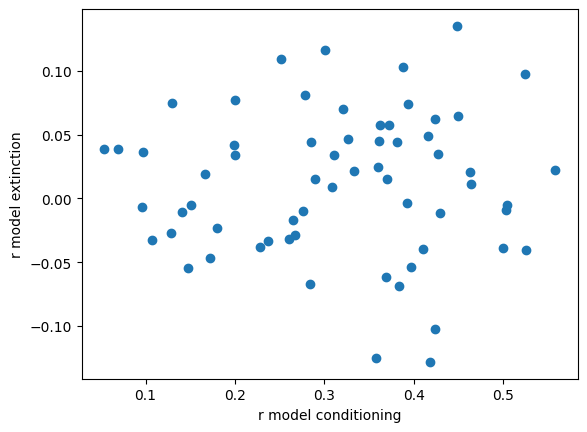

In [ ]:
#making scatterplot to compare r model conditioning and r model extinction

plt.scatter(r_model_conditioning, r_model_extinction)
plt.xlabel('r model conditioning')
plt.ylabel('r model extinction')

\\There seems to be strong correlation between shock conditioning and shock extinction based on pearson r, which is less than 0.05. Furthermore, visually, there appears to be a positive correlation between conditioning response and extinction response of cells.

#Coding Homework  #7

#Sasha Montgomery
<i>NEUR 265<i>

<b> April 22, 2026<b>


In [ ]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#loading data
acc_hits = np.loadtxt("https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/acc_hits_hw5.csv", delimiter = ",")
acc_fa = np.loadtxt("https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/acc_fa_hw5.csv", delimiter = ",")

In [ ]:
#printing shape of arrays
print("acc_hits shape:", acc_hits.shape)
print("acc_fa shape:", acc_fa.shape)


acc_hits shape: (24, 8001)
acc_fa shape: (19, 8001)


8001

 Both your acc_hits and acc_fa arrays consist of LFP data recorded from the mouse anterior cingulate cortex.

 - Rows of these arrays correspond to separate trials, and columns correspond to samples (timepoints).
- the task that the mouse was performing is called the continuous performance test.
- this test measures sustained attention.
- the mouse is rewarded (recieves some strawberry milkshake) when it responds to one type of stimulus. The stimulus is called the S+ (it usually looks like horizontal or vertical baclk and white bars).
- When the mouse responds to this stimulus, we call that response a hit.
- your acc_hits variable contains LFP surrounding these hits.
- In contrast, when the mouse is presented with another stimulus (the S-, which usually looks like a snowflake), it is not supposed to respond.
- When it does respond, that is called a false alarm.
- your acc_fa variable contains LFP surrounding these false alarms.
- so, you have two arrays -- one array with LFP recorded during correct choices (hits), and one array with LFP recorded during incorrect choices (false alarms).



In [ ]:
#creating time variable
time = np.linspace(0, 4, 8001)

In [ ]:
#determining sampling rate of data
sr = 8001/4


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1754/671153889.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage [$\mu V$]")
/tmp/ipykernel_1754/671153889.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage [$\mu V$]")


Text(0.5, 1.0, 'acc_fa trial 1')

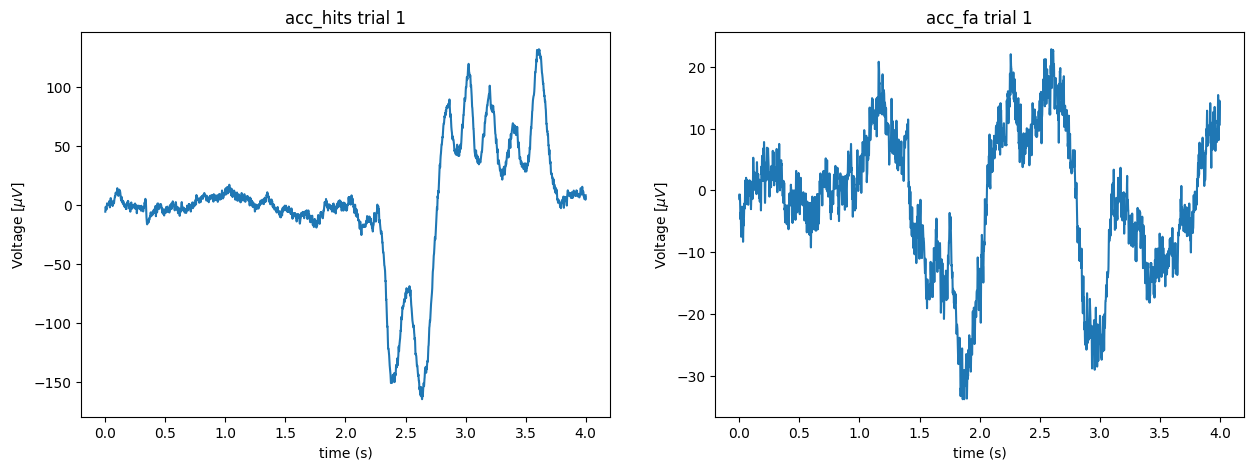

In [ ]:
#plotting first trial of acc_hits
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time, acc_hits[0])
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("Voltage [$\mu V$]")
ax[0].set_title("acc_hits trial 1")
ax[1].plot(time, acc_fa[0])
ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("Voltage [$\mu V$]")
ax[1].set_title("acc_fa trial 1")

I think the dominant oscillation in the LFP for the hits is 3z and for the false alarms is 1 hz.

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1754/2432627407.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Voltage [$\mu V$]')
/tmp/ipykernel_1754/2432627407.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Voltage [$\mu V$]')


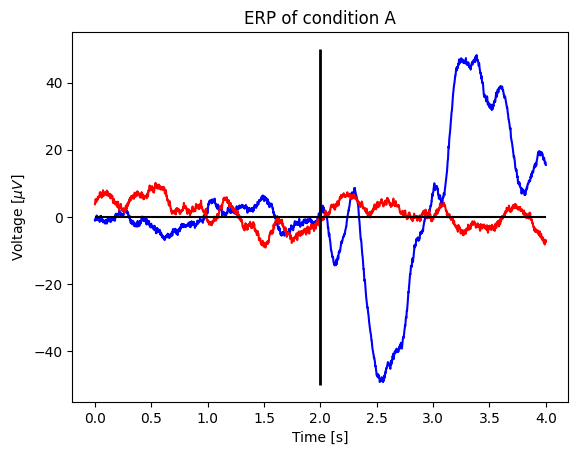

In [ ]:
#plotting ERP for acc_hits
plt.plot(time, acc_hits.mean(0), color= 'blue')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [$\mu V$]')
plt.title('ERP of acc_hits and acc_fa')
# Plot the ERP of acc_fa
plt.plot(time, acc_fa.mean(0), color = 'red')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [$\mu V$]')
plt.title('ERP of condition A')
plt.vlines(2, -50, 50, 'k', lw=2)
plt.hlines(0, time[0], time[-1], color = "black")


Are there any differences in the ERPs between hits and false alarms?  

The ERPs for the false alarms are flatter, meaning they are canceling eachother out across different trials. On the other hand, the hits are less flat, showing more consistency, especially after 2 seconds.

#Coding Homework #8
(extra homework practice)


In [13]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#importing relevant data
acc_hits = np.loadtxt("https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv", delimiter = ",")
acc_fa = np.loadtxt("https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv", delimiter = ",")
lc_hits = np.loadtxt("https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv", delimiter = ",")
lc_fa = np.loadtxt("https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv", delimiter = ",")



In [15]:
#showing shape of arrays
print("acc_hits shape:", acc_hits.shape)
print("acc_fa shape:", acc_fa.shape)
print("lc_hits:", lc_hits.shape)
print("lc_fa:", lc_fa.shape)

acc_hits shape: (14, 8001)
acc_fa shape: (19, 8001)
lc_hits: (14, 8001)
lc_fa: (19, 8001)


acc_hits and acc_fa is LFP data recorded from the mouse anterior cingulate cortex.

lc_hits and lc_fa arrays conssit of LFP data simultaneously recorded from the mouse locus coeruleus (an area in the brain with neurons that produce the neurotransmitter noepinephrine).

Rows of these arrays correspond to separate trials, and columns correspond to samples (timepoints).

rows = separate trials
columns = samples (timepoints)

task = continous performance test

continuous performance test measures sustained attention.
- the mouse is shaped to respond to a stimulus on a touchscreen.
- the mouse is rewarded (recieves strawberry milkshake) when it responds to one type of stimulus(this stimulus is called the S+)
- when mouse responds to this stimuus = response is a hit
- acc_hits and lc_hits variables contain LFP surrounding these hits.
- when mouse is presented with another stimulus (the S-, which usually looks like a snowflake) it is not supposed to respond.
- when it does respond, we call that a false alarm.
- acc_fa and lc_fa variables contain LFP surrounding these false alarms.

2 arrays with LFP recorded during correct choices (hits) and two arrays with LFP recorded during incorrect choices (false alarms).

In [16]:
#creating time variable
time = np.linspace(0, 4, 8001)

In [17]:
#determining sampling rate of data
sr = 8001/4


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1919/3027793583.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel('Voltage [$\mu V$]')
/tmp/ipykernel_1919/3027793583.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel('Voltage [$\mu V$]')


Text(0.5, 1.0, 'Acc_fa and lc_fa first trial')

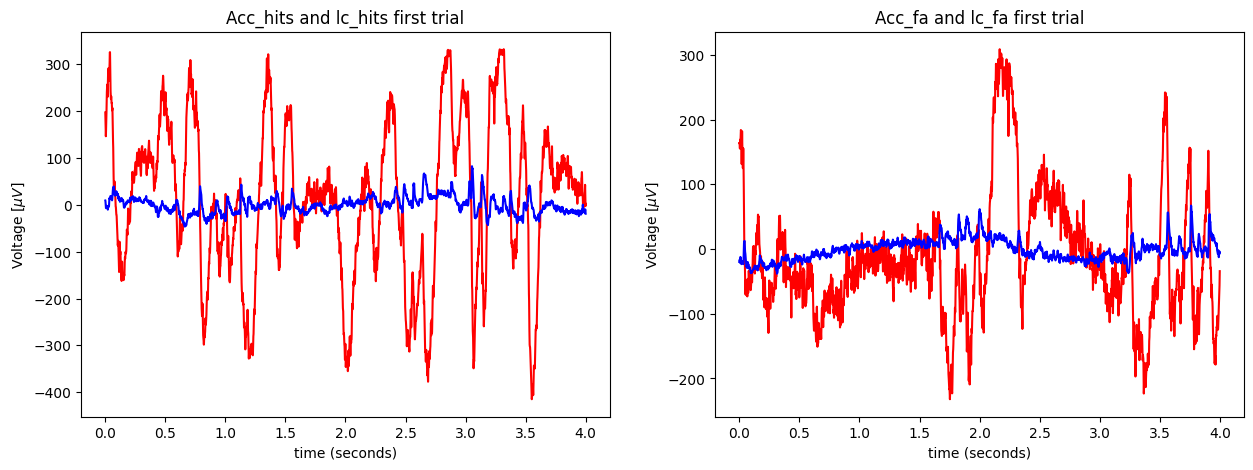

In [23]:
#plotting first trial of acc_hits and lc_hits
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(time, acc_hits[0], color = 'red')
ax[0].plot(time, lc_hits[0], color = 'blue')
ax[0].set_xlabel('time (seconds)')
ax[0].set_ylabel('Voltage [$\mu V$]')
ax[0].set_title('Acc_hits and lc_hits first trial')

ax[1].plot(time, acc_fa[0], color = 'red')
ax[1].plot(time, lc_fa[0], color = 'blue')
ax[1].set_xlabel('time (seconds)')
ax[1].set_ylabel('Voltage [$\mu V$]')
ax[1].set_title('Acc_fa and lc_fa first trial')



What do you think the dominant oscillation in the ACC LFP might be? What th edominant oscillation in the locus coeruleus (LC) LFP might be? Are the two different? By visual inspection do you notie any relationship between the two brain areas during the "hit" you plotted, or the "false alarm" you plotted? Recall from our notebook on phase coherence that sometimes the peaks and troughs of two oscillations have a consistent relationship across time. Is there any evidence of this in the raw LFP?

Text(0.5, 1.0, 'Trial averaged autocovariance lc_hits')

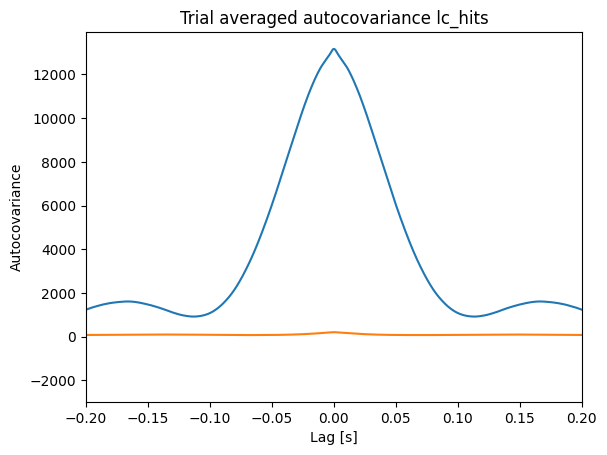

In [28]:
#computing autocovariance for acc_hits and lc_hits

#calculating autocovariance for each
# Define the sampling interval.
dt = time[1] - time[0]
# Define the number of trials.
K = acc_hits.shape[0]
# Define number of points in each trial.
N = acc_hits.shape[1]
# Declare empty vector for autocov.
ac = np.zeros([2 * N - 1])

# For each trial,
for trial in acc_hits:
  # ... subtract the mean,
    x = trial - trial.mean()
    # ... compute autocovar,
    ac0 = 1 / N * np.correlate(x, x, 'full')
    # ... and add to total, scaled by 1/K.
    ac += ac0 / K;

      # Create a lag axis,
lags = np.arange(-N + 1, N)
# ... and plot the result.
plt.plot(lags * dt, ac)
plt.xlim([-0.2, 0.2])
plt.xlabel('Lag [s]')
plt.ylabel('Autocovariance');
plt.title('Trial averaged autocovariance acc_hits')


#calculating autocovariance for each
# Define the sampling interval.
dt = time[1] - time[0]
# Define the number of trials.
K = lc_hits.shape[0]
# Define number of points in each trial.
N = lc_hits.shape[1]
# Declare empty vector for autocov.
ac = np.zeros([2 * N - 1])

# For each trial,
for trial in lc_hits:
  # ... subtract the mean,
    x = trial - trial.mean()
    # ... compute autocovar,
    ac0 = 1 / N * np.correlate(x, x, 'full')
    # ... and add to total, scaled by 1/K.
    ac += ac0 / K;

      # Create a lag axis,
lags = np.arange(-N + 1, N)
# ... and plot the result.
plt.plot(lags * dt, ac)
plt.xlim([-0.2, 0.2])
plt.xlabel('Lag [s]')
plt.ylabel('Autocovariance');
plt.title('Trial averaged autocovariance lc_hits')

Text(0.5, 1.0, 'Coherence between acc_hits and lc_hits')

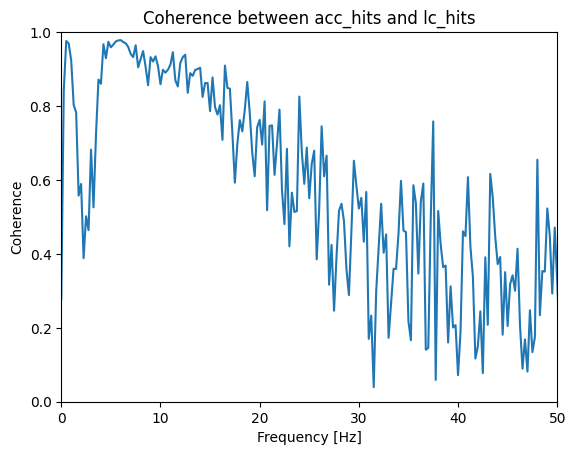

In [29]:
#computing coherence for acc_hits and lc_hits

# Compute the Fourier transforms
# ... for each trial in E1
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])
# ... and each trial in E2
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
# Spectrum of E1 trials
Sxx = scale * (xf * xf.conj()).mean(0)
# ... and E2 trials
Syy = scale * (yf * yf.conj()).mean(0)
# ... and the cross spectrum
Sxy = scale * (xf * yf.conj()).mean(0)

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

 # Define a frequency axis.
f = np.fft.rfftfreq(N, dt)
# Plot coherence vs frequency,
plt.plot(f, cohr.real)
# ... in a chosen frequency range,
plt.xlim([0, 50])
 # ... with y-axis scaled,
plt.ylim([0, 1])
   # ... and with axes labeled.
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Coherence between acc_hits and lc_hits')


The frequency band between 0 and 10 shows the most phase coherence during hits.

Text(0.5, 1.0, 'Trial averaged autocovariance lc_fa')

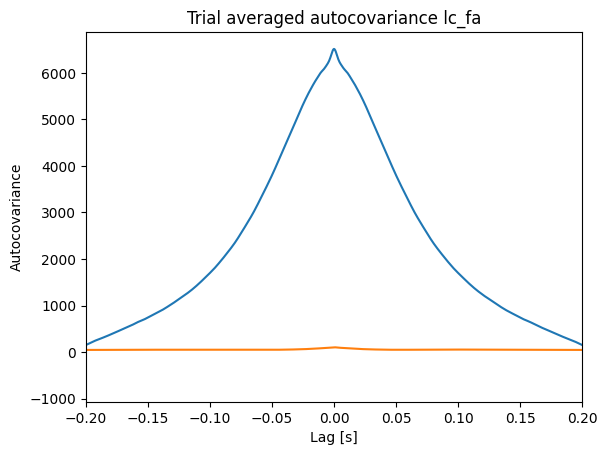

In [32]:
#computing autocovariance for acc_fa and lc_fa

#calculating autocovariance for each
# Define the sampling interval.
dt = time[1] - time[0]
# Define the number of trials.
K = acc_fa.shape[0]
# Define number of points in each trial.
N = acc_fa.shape[1]
# Declare empty vector for autocov.
ac = np.zeros([2 * N - 1])

# For each trial,
for trial in acc_fa:
  # ... subtract the mean,
    x = trial - trial.mean()
    # ... compute autocovar,
    ac0 = 1 / N * np.correlate(x, x, 'full')
    # ... and add to total, scaled by 1/K.
    ac += ac0 / K;

      # Create a lag axis,
lags = np.arange(-N + 1, N)
# ... and plot the result.
plt.plot(lags * dt, ac)
plt.xlim([-0.2, 0.2])
plt.xlabel('Lag [s]')
plt.ylabel('Autocovariance');
plt.title('Trial averaged autocovariance acc_fa')


#calculating autocovariance for each
# Define the sampling interval.
dt = time[1] - time[0]
# Define the number of trials.
K = lc_fa.shape[0]
# Define number of points in each trial.
N = lc_fa.shape[1]
# Declare empty vector for autocov.
ac = np.zeros([2 * N - 1])

# For each trial,
for trial in lc_fa:
  # ... subtract the mean,
    x = trial - trial.mean()
    # ... compute autocovar,
    ac0 = 1 / N * np.correlate(x, x, 'full')
    # ... and add to total, scaled by 1/K.
    ac += ac0 / K;

      # Create a lag axis,
lags = np.arange(-N + 1, N)
# ... and plot the result.
plt.plot(lags * dt, ac)
plt.xlim([-0.2, 0.2])
plt.xlabel('Lag [s]')
plt.ylabel('Autocovariance');
plt.title('Trial averaged autocovariance lc_fa')

Text(0.5, 1.0, 'Coherence between acc_fa and lc_fa')

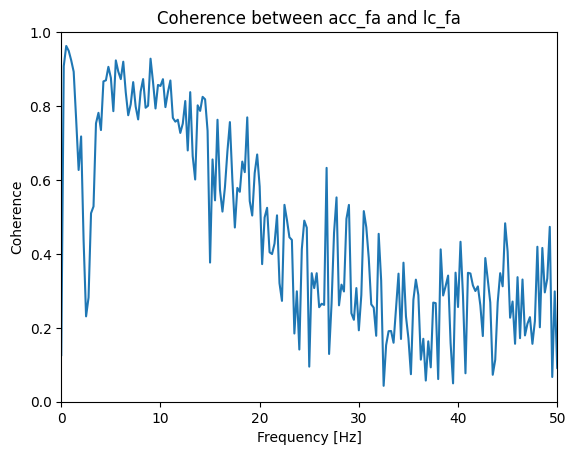

In [31]:
#computing coherence for acc_fa and lc_fa

# Compute the Fourier transforms
# ... for each trial in E1
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_fa])
# ... and each trial in E2
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_fa])

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
# Spectrum of E1 trials
Sxx = scale * (xf * xf.conj()).mean(0)
# ... and E2 trials
Syy = scale * (yf * yf.conj()).mean(0)
# ... and the cross spectrum
Sxy = scale * (xf * yf.conj()).mean(0)

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

 # Define a frequency axis.
f = np.fft.rfftfreq(N, dt)
# Plot coherence vs frequency,
plt.plot(f, cohr.real)
# ... in a chosen frequency range,
plt.xlim([0, 50])
 # ... with y-axis scaled,
plt.ylim([0, 1])
   # ... and with axes labeled.
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Coherence between acc_fa and lc_fa')


The frequency band between 0 and 10 shows the most phase coherence during false alarms.

The frequency at which the coherence is strongest is the same between hits and false alarms. But, coherence is higher during flase alarms. Higher coherence = more communication between the ACC and the LC, so these two brain areas are talking to eachother more during hits instead of false alarms.